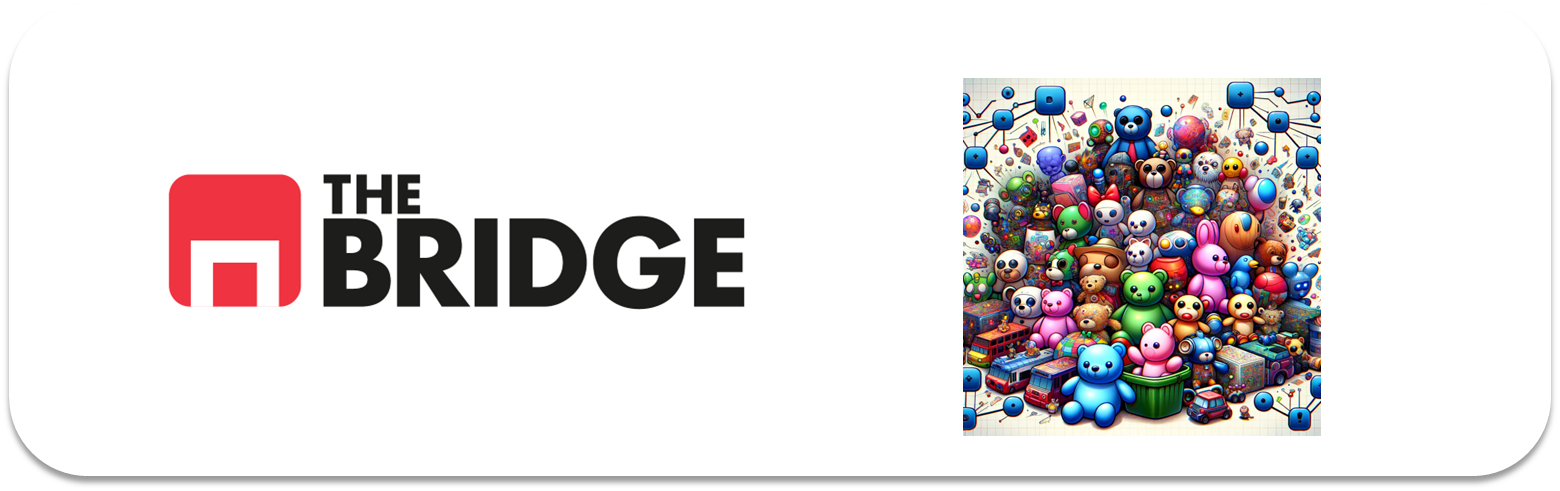

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.options.mode.copy_on_write = True 


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Usuario\scikit_learn_data


In [3]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2 

Muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [4]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [5]:
len(olivetti.data)

400

In [6]:
range(4096)

range(0, 4096)

In [7]:
df_olivetti = pd.DataFrame(olivetti.data, columns = [f"pixel_{i}" for i in range(4096)])
df_olivetti

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


In [8]:
df_olivetti["cara"] = olivetti.target

In [9]:
df_olivetti_back = df_olivetti.copy()

In [10]:
df_olivetti_back.sample(len(df_olivetti_back), random_state=42)

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,cara
209,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
280,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
33,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
210,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
93,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.194215,0.223140,0.314050,0.500000,0.636364,0.735537,0.797521,0.826446,0.847107,0.847107,...,0.206612,0.181818,0.165289,0.123967,0.123967,0.128099,0.136364,0.169421,0.165289,7
106,0.260331,0.355372,0.648760,0.822314,0.838843,0.834711,0.830579,0.826446,0.822314,0.814050,...,0.264463,0.185950,0.136364,0.177686,0.132231,0.103306,0.103306,0.107438,0.119835,10
270,0.611570,0.644628,0.657025,0.669421,0.673554,0.710744,0.735537,0.756198,0.760331,0.768595,...,0.152893,0.107438,0.119835,0.132231,0.111570,0.136364,0.177686,0.210744,0.223140,27
348,0.285124,0.293388,0.297521,0.293388,0.219008,0.107438,0.342975,0.508264,0.533058,0.557851,...,0.388430,0.442149,0.475207,0.500000,0.516529,0.520661,0.533058,0.533058,0.537190,34


In [11]:
df_olivetti = df_olivetti_back.sample(len(df_olivetti_back), random_state= 42)
df_olivetti.cara

209    20
280    28
33      3
210    21
93      9
       ..
71      7
106    10
270    27
348    34
102    10
Name: cara, Length: 400, dtype: int64

### #1.3

Vamos a dividir en train y test pero, OJO, RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es una práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (320 registros-40 registros-40 registros). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 360-40 (resto-test) en registros y luego otro split sobre los 360 en 280-80. (train-validation)

In [12]:
df_olivetti.cara.value_counts(True)

cara
20    0.025
28    0.025
3     0.025
21    0.025
9     0.025
8     0.025
32    0.025
26    0.025
12    0.025
0     0.025
36    0.025
5     0.025
7     0.025
13    0.025
4     0.025
27    0.025
37    0.025
23    0.025
38    0.025
1     0.025
39    0.025
11    0.025
22    0.025
10    0.025
19    0.025
34    0.025
15    0.025
14    0.025
2     0.025
18    0.025
17    0.025
33    0.025
29    0.025
25    0.025
35    0.025
24    0.025
6     0.025
30    0.025
31    0.025
16    0.025
Name: proportion, dtype: float64

In [13]:
train_set, val_test_set = train_test_split(df_olivetti, test_size = 80, stratify= df_olivetti["cara"], random_state= 42) # train_size
validation_set, test_set = train_test_split(val_test_set, test_size = 40, stratify= val_test_set["cara"], random_state= 43)

In [14]:
print(len(test_set))
print(len(validation_set))
print(len(train_set))

40
40
320


### #1.4

Crea los pares X, y para train, validation y test.

In [15]:
X_train = train_set.drop("cara", axis = 1)
X_valid = validation_set.drop("cara", axis = 1)
X_test = test_set.drop("cara", axis = 1)

y_train = train_set["cara"]
y_valid = validation_set["cara"]
y_test = test_set["cara"]

Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [16]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64) # (4096,) -> (64,64) (128,32) (2048,2)
    n_rows = (len(faces) - 1) // n_cols + 1
    
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray") # image show -> imprimir imagenes
        plt.axis("off")
        plt.title(label)
    plt.show()

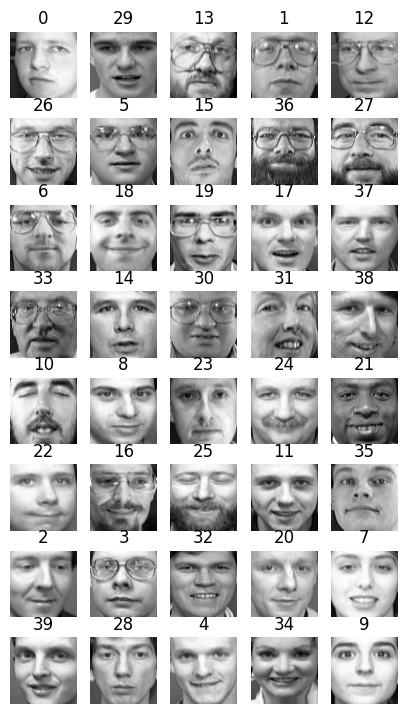

In [17]:
plot_faces(X_valid.values, y_valid)

In [18]:
X_train

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
130,0.632231,0.652893,0.582645,0.636364,0.636364,0.706612,0.747934,0.780992,0.793388,0.814050,...,0.256198,0.285124,0.272727,0.210744,0.231405,0.223140,0.107438,0.082645,0.090909,0.090909
50,0.719008,0.727273,0.723140,0.714876,0.723140,0.731405,0.739669,0.760331,0.780992,0.793388,...,0.516529,0.500000,0.438017,0.566116,0.743802,0.566116,0.314050,0.301653,0.338843,0.322314
36,0.185950,0.342975,0.512397,0.570248,0.628099,0.615702,0.652893,0.661157,0.685950,0.727273,...,0.404959,0.351240,0.326446,0.355372,0.429752,0.487603,0.371901,0.301653,0.322314,0.318182
120,0.371901,0.487603,0.566116,0.586777,0.590909,0.615702,0.657025,0.665289,0.673554,0.685950,...,0.309917,0.280992,0.297521,0.351240,0.396694,0.421488,0.438017,0.371901,0.619835,0.590909
102,0.326446,0.144628,0.260331,0.752066,0.847107,0.851240,0.847107,0.847107,0.851240,0.842975,...,0.384298,0.376033,0.334711,0.243802,0.210744,0.157025,0.181818,0.140496,0.301653,0.157025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.669421,0.677686,0.673554,0.673554,0.657025,0.636364,0.648760,0.644628,0.648760,0.685950,...,0.462810,0.359504,0.219008,0.210744,0.219008,0.210744,0.223140,0.223140,0.219008,0.223140
276,0.706612,0.702479,0.735537,0.780992,0.789256,0.772727,0.789256,0.789256,0.789256,0.776860,...,0.202479,0.140496,0.152893,0.161157,0.148760,0.181818,0.210744,0.152893,0.177686,0.107438
216,0.181818,0.338843,0.355372,0.404959,0.438017,0.458678,0.471074,0.479339,0.491736,0.479339,...,0.152893,0.285124,0.392562,0.256198,0.396694,0.433884,0.392562,0.392562,0.454545,0.454545
20,0.578512,0.603306,0.632231,0.665289,0.677686,0.710744,0.723140,0.739669,0.739669,0.743802,...,0.157025,0.177686,0.194215,0.198347,0.206612,0.194215,0.165289,0.177686,0.161157,0.152893


### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [20]:
X_train

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4086,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095
130,0.632231,0.652893,0.582645,0.636364,0.636364,0.706612,0.747934,0.780992,0.793388,0.814050,...,0.256198,0.285124,0.272727,0.210744,0.231405,0.223140,0.107438,0.082645,0.090909,0.090909
50,0.719008,0.727273,0.723140,0.714876,0.723140,0.731405,0.739669,0.760331,0.780992,0.793388,...,0.516529,0.500000,0.438017,0.566116,0.743802,0.566116,0.314050,0.301653,0.338843,0.322314
36,0.185950,0.342975,0.512397,0.570248,0.628099,0.615702,0.652893,0.661157,0.685950,0.727273,...,0.404959,0.351240,0.326446,0.355372,0.429752,0.487603,0.371901,0.301653,0.322314,0.318182
120,0.371901,0.487603,0.566116,0.586777,0.590909,0.615702,0.657025,0.665289,0.673554,0.685950,...,0.309917,0.280992,0.297521,0.351240,0.396694,0.421488,0.438017,0.371901,0.619835,0.590909
102,0.326446,0.144628,0.260331,0.752066,0.847107,0.851240,0.847107,0.847107,0.851240,0.842975,...,0.384298,0.376033,0.334711,0.243802,0.210744,0.157025,0.181818,0.140496,0.301653,0.157025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.669421,0.677686,0.673554,0.673554,0.657025,0.636364,0.648760,0.644628,0.648760,0.685950,...,0.462810,0.359504,0.219008,0.210744,0.219008,0.210744,0.223140,0.223140,0.219008,0.223140
276,0.706612,0.702479,0.735537,0.780992,0.789256,0.772727,0.789256,0.789256,0.789256,0.776860,...,0.202479,0.140496,0.152893,0.161157,0.148760,0.181818,0.210744,0.152893,0.177686,0.107438
216,0.181818,0.338843,0.355372,0.404959,0.438017,0.458678,0.471074,0.479339,0.491736,0.479339,...,0.152893,0.285124,0.392562,0.256198,0.396694,0.433884,0.392562,0.392562,0.454545,0.454545
20,0.578512,0.603306,0.632231,0.665289,0.677686,0.710744,0.723140,0.739669,0.739669,0.743802,...,0.157025,0.177686,0.194215,0.198347,0.206612,0.194215,0.165289,0.177686,0.161157,0.152893


In [21]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

In [22]:
np.cumsum(pca.explained_variance_ratio_)

array([0.24218799, 0.38268432, 0.46095803, 0.5113758 , 0.54622835,
       0.579085  , 0.6038183 , 0.62378263, 0.6435662 , 0.66023576,
       0.67521113, 0.6893009 , 0.7023265 , 0.7138657 , 0.7245691 ,
       0.7343729 , 0.7438337 , 0.7523935 , 0.76029503, 0.7677593 ,
       0.7747294 , 0.78132844, 0.7873086 , 0.7930764 , 0.79846334,
       0.80377936, 0.80889195, 0.81353575, 0.81817406, 0.822528  ,
       0.8265746 , 0.83045346, 0.8341705 , 0.83759356, 0.8409036 ,
       0.844123  , 0.8472286 , 0.85019356, 0.8531176 , 0.8559309 ,
       0.8586056 , 0.861193  , 0.86366916, 0.86604387, 0.86837786,
       0.87068284, 0.8729279 , 0.8751219 , 0.87725896, 0.879366  ,
       0.8813918 , 0.8834015 , 0.88533646, 0.8872298 , 0.8890926 ,
       0.89089316, 0.8926366 , 0.89436316, 0.8960343 , 0.8976367 ,
       0.8992061 , 0.90076566, 0.9023083 , 0.9038201 , 0.9052813 ,
       0.90673393, 0.9081569 , 0.9095601 , 0.9109373 , 0.912279  ,
       0.9136158 , 0.9149193 , 0.91619873, 0.9174257 , 0.91864

In [23]:
pd.DataFrame(X_train_pca, columns= [f"feat_new_{i}" for i in range(1,pca.n_components_+1)])

,feat_new_1,feat_new_2,feat_new_3,feat_new_4,feat_new_5,feat_new_6,feat_new_7,feat_new_8,feat_new_9,feat_new_10,...,feat_new_212,feat_new_213,feat_new_214,feat_new_215,feat_new_216,feat_new_217,feat_new_218,feat_new_219,feat_new_220,feat_new_221
0,0.526405,2.222136,1.068338,-1.799268,-0.718531,1.524710,1.440414,-2.113228,1.996764,-0.587920,...,0.254084,0.115938,-0.190304,0.003485,-0.163545,0.357895,-0.104744,-0.189394,-0.079530,-0.136155
1,4.355064,2.870468,-0.259205,2.452003,3.452973,-1.514500,1.363052,0.492718,-0.245750,0.741315,...,0.406226,-0.125008,-0.194352,0.031091,0.146731,0.105379,-0.090906,0.068433,-0.034207,0.112854
2,4.598089,-0.380966,-0.637658,-0.296070,-0.376373,0.982518,0.795213,-0.804183,-0.506562,0.792176,...,-0.125867,0.094671,-0.142763,-0.072476,0.173203,0.131946,0.110542,-0.220713,-0.056120,-0.053086
3,-0.847230,-0.746171,-0.085553,-0.634098,0.677862,2.146528,1.798230,-1.140560,1.234181,-0.076505,...,0.044736,0.123464,0.153583,0.044763,0.221051,-0.061761,0.151249,0.221545,-0.046954,0.076481
4,3.364857,3.805036,-2.646902,-2.462322,-1.136403,1.312299,-0.373387,-1.876032,-1.871709,0.409600,...,0.134897,0.151106,0.115116,-0.143995,0.067750,0.032168,0.036775,0.007391,-0.006938,-0.324692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,-4.455243,1.958483,-2.402823,0.615186,-1.063918,0.293730,1.641580,1.163177,-2.407047,2.074335,...,0.042580,-0.091021,0.102353,0.006262,-0.171369,0.062295,-0.062790,0.117041,0.033105,-0.240358
316,0.224610,2.349912,-0.540406,-3.880439,-0.088340,2.083114,1.070112,1.195287,-3.036188,-0.982565,...,-0.165956,-0.079971,-0.151520,-0.012300,-0.110956,0.072075,-0.067871,0.049411,0.112906,-0.028477
317,-10.044879,-0.453787,-0.332880,0.322790,-0.293132,-1.408977,-0.135373,1.448696,-1.582112,0.459673,...,-0.151865,-0.011807,-0.003028,-0.113288,-0.064960,-0.039877,0.007389,-0.002261,-0.028705,-0.125910
318,-2.732218,2.213702,2.782173,-0.212001,1.319137,0.554627,0.233089,1.624781,-1.813847,-1.339302,...,0.055199,-0.132768,0.184986,-0.059819,-0.034259,-0.216147,0.152706,-0.173462,-0.250349,-0.038320


In [25]:
len(pca.inverse_transform(X_train_pca[0].reshape(1, -1)))

1

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas)

In [26]:
from sklearn.cluster import KMeans

k_range = range(5, 151, 5)
kmeans_model_list = []

for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_model_list.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145
k=150


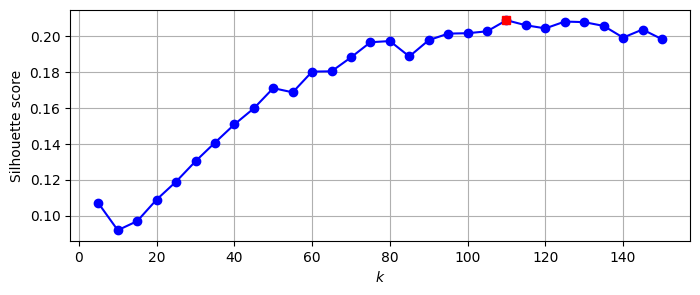

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_) for model in kmeans_model_list]

best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index] # Esto para pintarlo 
best_score = silhouette_scores[best_index] # equivalente a max(silhouette_scores)

plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [28]:
best_k

110

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

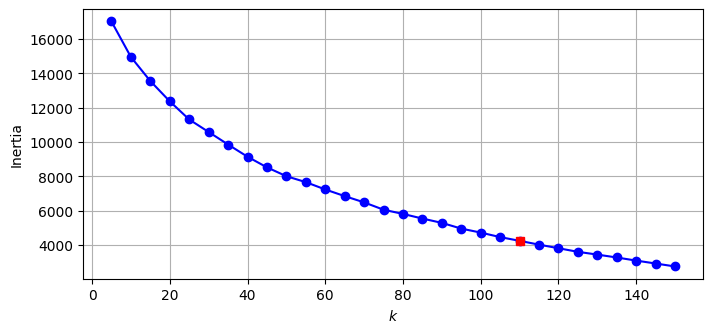

In [29]:
inertias = [model.inertia_ for model in kmeans_model_list]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [30]:
best_model = kmeans_model_list[best_index]
best_model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",110
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Cluster 0


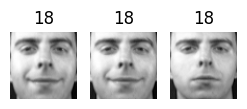

Cluster 1


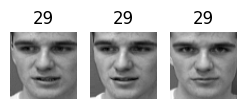

Cluster 2


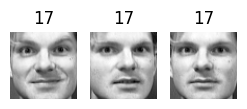

Cluster 3


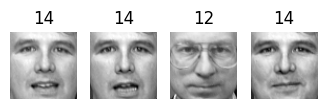

Cluster 4


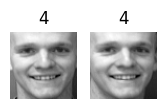

Cluster 5


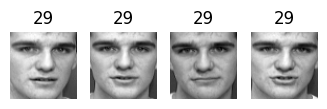

Cluster 6


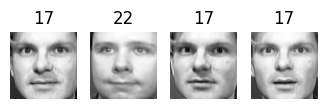

Cluster 7


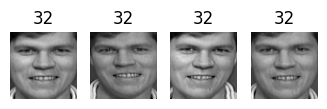

Cluster 8


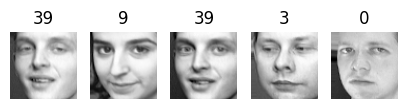

Cluster 9


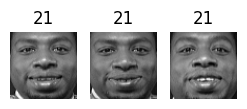

Cluster 10


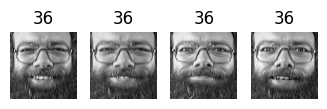

Cluster 11


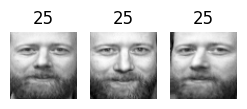

Cluster 12


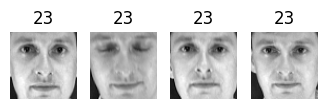

Cluster 13


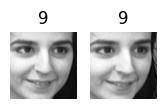

Cluster 14


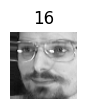

Cluster 15


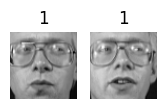

Cluster 16


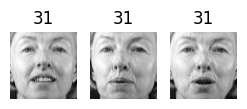

Cluster 17


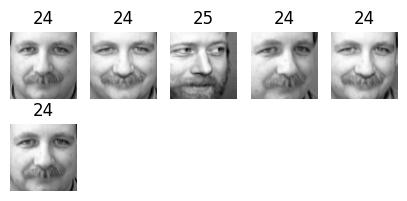

Cluster 18


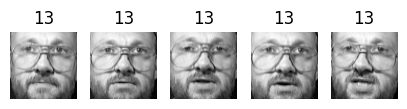

Cluster 19


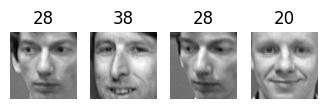

Cluster 20


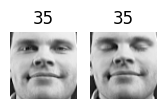

Cluster 21


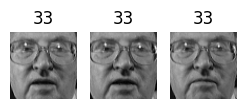

Cluster 22


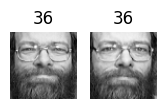

Cluster 23


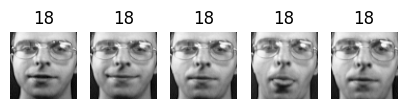

Cluster 24


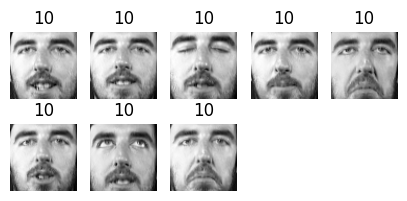

Cluster 25


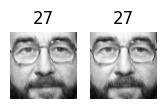

Cluster 26


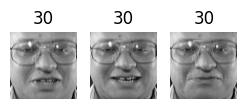

Cluster 27


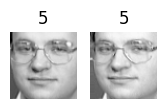

Cluster 28


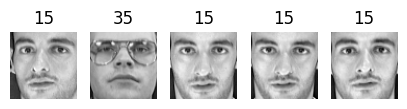

Cluster 29


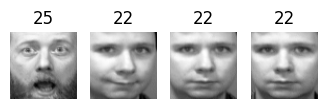

In [31]:
for cluster_id in np.unique(best_model.labels_)[0:30]:
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster].values
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

Un pporcentaje alto de las agrupaciones son correctas: tienen al menos dos fotos y todas son de la misma persona. Los demás grupos suelen tener algún fallo, como imágenes mezcladas o grupos con solo una foto que no sirven mucho.

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [32]:
len(X_train_pca)

320

In [33]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train) # Con set PCA
clf.score(X_valid_pca, y_valid)

0.925

In [34]:

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train, y_train) # Con set completo 4096 features
clf.score(X_valid, y_valid)

0.925

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [35]:
best_model

KMeans(n_clusters=120, n_init=10, random_state=42)

In [35]:
X_train_reducido = best_model.transform(X_train_pca)
X_valid_reducido = best_model.transform(X_valid_pca)
X_test_reducido = best_model.transform(X_test_pca)


In [36]:
X_train_pca.shape

(320, 221)

In [37]:
X_train_reducido.shape

(320, 110)

In [39]:
best_model.cluster_centers_[0]

array([-3.68777466e+00,  1.71494305e+00, -2.24364996e+00,  1.08943295e+00,
       -6.03816390e-01,  7.55057156e-01,  1.54877257e+00,  1.70019746e+00,
       -2.04166484e+00,  1.21393859e+00, -2.23515034e+00,  2.63018906e-01,
       -3.06543916e-01, -9.49462354e-01, -1.22987831e+00,  3.66124185e-03,
       -8.13157205e-03, -4.54900175e-01, -1.43954420e+00,  6.92382991e-01,
       -8.76032591e-01, -8.65791142e-01,  6.36864230e-02,  5.32753229e-01,
       -6.73100352e-01,  1.06688559e-01,  4.73108530e-01,  5.47772765e-01,
       -4.99103278e-01,  3.64153802e-01, -9.36345279e-01, -1.46435410e-01,
        5.07647032e-03,  7.47540236e-01,  4.40071821e-01, -8.01819935e-03,
       -2.22289309e-01, -8.39871988e-02,  6.97091341e-01, -9.58225727e-02,
       -2.01747119e-01,  1.82549313e-01,  8.02996308e-02,  7.00969249e-02,
       -2.77331680e-01,  8.05797040e-01,  2.86653340e-01, -1.34541079e-01,
        9.26215723e-02,  4.30580527e-01, -2.36893505e-01,  3.58720720e-01,
        5.12674034e-01,  

In [38]:
pd.DataFrame(X_train_reducido)

,0,1,2,3,4,5,6,7,8,9,...,100,101,102,103,104,105,106,107,108,109
0,10.353889,11.207098,10.077947,7.829199,9.679150,9.965013,10.545458,13.043637,12.711199,14.343015,...,11.623594,9.980484,9.261310,11.759036,10.581501,12.192366,11.419432,1.069246e+01,13.669904,12.294965
1,9.115041,11.145270,7.727826,8.594296,8.403509,8.902900,9.232792,13.031004,12.129411,16.625643,...,10.908019,10.131697,7.912279,10.486427,7.824502,12.101656,10.268800,1.460010e-07,12.176520,9.634481
2,8.533899,11.551460,7.071287,6.572448,10.762480,9.618140,6.802994,12.680964,8.688995,16.009947,...,11.522585,8.831941,8.102863,8.347302,6.929993,8.814554,10.551063,8.552167e+00,10.497371,9.950581
3,10.779476,8.535616,8.597699,5.363557,8.981158,7.963552,9.246170,10.297263,10.744782,12.210640,...,12.073520,8.339550,8.945623,10.271352,10.397212,11.694547,10.620370,1.044433e+01,12.162447,12.438816
4,7.925747,12.618046,9.796701,8.965103,11.996790,11.389176,10.434989,14.954891,13.212239,16.493065,...,12.786725,10.503304,9.914558,11.414998,10.559896,13.233529,11.273925,1.070717e+01,12.509908,10.762529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,11.799118,8.752539,12.038960,8.893382,10.534796,9.284957,13.911134,11.746325,14.791854,10.429775,...,13.680613,9.009618,10.479249,11.610978,13.726088,15.177107,10.992739,1.290736e+01,15.113099,14.650702
316,10.182042,12.575252,11.150601,10.414865,11.844268,11.165351,12.381938,14.300536,13.499618,14.670196,...,13.380735,10.237554,11.296410,12.636273,12.888337,14.562427,13.049616,1.211329e+01,12.919302,12.612311
317,16.438354,10.301123,16.014221,12.827783,12.185143,11.159774,17.521372,10.946602,17.518908,5.679394,...,16.581678,12.688376,14.723969,16.198278,18.026041,18.334003,15.359406,1.690865e+01,18.420078,18.617294
318,10.598342,8.586517,9.731663,8.130946,6.916448,7.510092,11.743942,11.318887,13.410705,11.038100,...,9.999714,9.411157,9.413484,11.582921,11.452682,13.876453,12.724341,1.081030e+01,13.457734,13.065707


In [39]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reducido, y_train)
    
clf.score(X_valid_reducido, y_valid)

0.825